# 01. Разведочный анализ данных (EDA)

Цель: изучить структуру датасета, выявить проблемы качества данных
и сформулировать требования к этапу предобработки.

Датасет: корпус публикаций из русскоязычных Telegram-каналов,
собранных за период 2015–2025 гг.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# Директория для артефактов
os.makedirs("figures", exist_ok=True)

# Стиль графиков
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

In [25]:
raw_df = pd.read_parquet("data/posts.parquet", engine="fastparquet")

## 1. Общая характеристика датасета

In [17]:
print(f"Всего записей: {len(raw_df):,}")
print(f"Уникальных каналов: {raw_df['channel_name'].nunique():,}")
print(f"Период: {raw_df['post_date'].min().date()} -> {raw_df['post_date'].max().date()}")
print("\nТипы колонок:")
print(raw_df.dtypes)
print("\nПропуски:")
print(raw_df.isnull().sum())

Всего записей: 3,035,065
Уникальных каналов: 67
Период: 2015-12-28 -> 2025-06-24

Типы колонок:
id_post                       int64
channel_name                 object
post_date       datetime64[ns, UTC]
text                         object
views                       float64
reactions                     int64
comments                      int64
dtype: object

Пропуски:
id_post         0
channel_name    0
post_date       0
text            0
views           5
reactions       0
comments        0
dtype: int64


**Наблюдения:**
- Датасет содержит 3 035 065 записей из 67 уникальных каналов
- Временной охват почти 10 лет (2015–2025)
- Пропуски присутствуют только в колонке `views` (5 записей), что некритично
- Колонка `text` пропусков не содержит, данные собраны аккуратно

## 2. Анализ длины текстов

Длина текста влияет на качество эмбеддингов и кластеризации.
Слишком короткие тексты не несут достаточно семантической информации
для корректного определения темы.

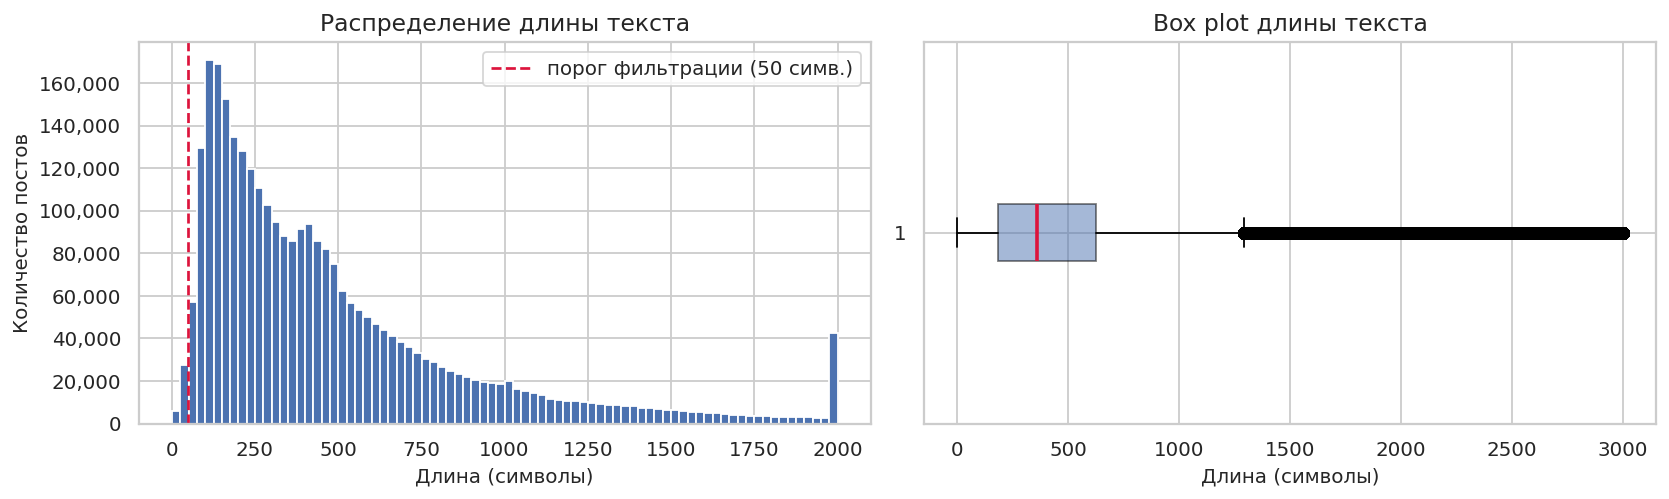

--- Статистика длины текста ---
count    3035065.0
mean         488.3
std          446.9
min            1.0
25%          184.0
50%          358.0
75%          627.0
90%         1041.0
95%         1390.0
99%         2105.0
max         7730.0
Name: text_len, dtype: float64

Коротких постов (<50 симв.): 31,848 (1.0%)


In [26]:
raw_df["text_len"] = raw_df["text"].fillna("").str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(
    raw_df["text_len"].clip(upper=2000),
    bins=80,
    color="#4C72B0",
    edgecolor="white"
)
axes[0].axvline(50, color="crimson", linestyle="--", linewidth=1.5, label="порог фильтрации (50 симв.)")
axes[0].set_title("Распределение длины текста")
axes[0].set_xlabel("Длина (символы)")
axes[0].set_ylabel("Количество постов")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].legend()

# Box plot
axes[1].boxplot(
    raw_df["text_len"].clip(upper=3000),
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="#4C72B0", alpha=0.5),
    medianprops=dict(color="crimson", linewidth=2)
)
axes[1].set_title("Box plot длины текста")
axes[1].set_xlabel("Длина (символы)")

plt.tight_layout()
plt.savefig("figures/01_text_length.png", bbox_inches="tight")
plt.show()

print("--- Статистика длины текста ---")
print(raw_df["text_len"].describe(percentiles=[.25, .5, .75, .90, .95, .99]).round(1))

min_text_len = 50
short = (raw_df["text_len"] < min_text_len).sum()
print(f"\nКоротких постов (<{min_text_len} симв.): {short:,} ({short/len(raw_df)*100:.1f}%)")

**Наблюдения:**
- Медианная длина поста составляет 358 символов, что достаточно для тематического моделирования
- Распределение правостороннее, большинство постов умеренной длины (184–627 символов, IQR)
- 1% постов (31 848 записей) короче 50 символов -> они будут исключены на этапе предобработки
как семантически недостаточные для тематической классификации

## 3. Временная динамика публикаций

Анализ распределения публикаций во времени позволяет оценить
пригодность датасета для задачи Topic Evolution -
отслеживания изменений тематики между временными срезами

C:\Users\kadi\AppData\Local\Temp\ipykernel_29072\2933016133.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  raw_df["year_month"] = raw_df["post_date"].dt.to_period("M")


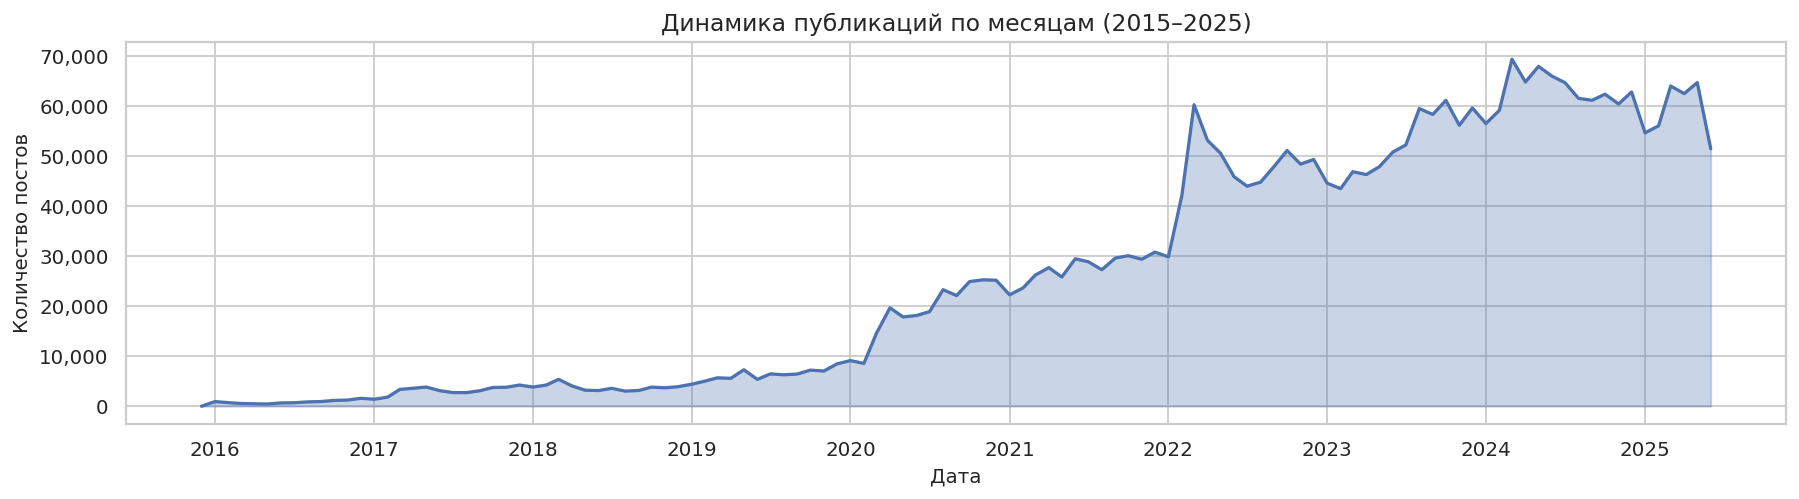

Топ-5 месяцев по объему:
year_month  count
   2024-03  69440
   2024-05  68014
   2024-06  66052
   2024-04  64879
   2025-05  64772

Распределение по годам:
post_date
2015         4
2016     10385
2017     37585
2018     45138
2019     75425
2020    227985
2021    331623
2022    568018
2023    627615
2024    757537
2025    353750
Name: count, dtype: int64


In [30]:
raw_df["year_month"] = raw_df["post_date"].dt.to_period("M")
monthly = (
    raw_df.groupby("year_month")
    .size()
    .reset_index(name="count")
)
monthly["dt"] = monthly["year_month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(monthly["dt"], monthly["count"], alpha=0.3, color="#4C72B0")
ax.plot(monthly["dt"], monthly["count"], color="#4C72B0", linewidth=1.8)
ax.set_title("Динамика публикаций по месяцам (2015–2025)")
ax.set_xlabel("Дата")
ax.set_ylabel("Количество постов")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("figures/02_temporal_dynamics.png", bbox_inches="tight")
plt.show()

print("Топ-5 месяцев по объему:")
print(monthly.nlargest(5, "count")[["year_month", "count"]].to_string(index=False))

print("\nРаспределение по годам:")
print(raw_df["post_date"].dt.year.value_counts().sort_index())

**Наблюдения:**
- Объем публикаций монотонно растет с 2016 по 2024 год
- Наиболее активный период 2024 год (757 537 постов), что соответствует пику развития Telegram как новостной платформы в России
- Топ-5 месяцев по объему - март–июнь 2024, что вероятно связано с интенсивным освещением геополитических событий
- 2015 год представлен лишь 4 записями, поэтому эти данные будут исключены при формировании темпоральных срезов

## 4. Сезонное распределение

Проверяем наличие сезонного смещения, которое могло бы исказить
результаты Topic Evolution при сравнении срезов разных периодов.

In [28]:
season_map = {12:'Зима',1:'Зима',2:'Зима',
              3:'Весна',4:'Весна',5:'Весна',
              6:'Лето',7:'Лето',8:'Лето',
              9:'Осень',10:'Осень',11:'Осень'}

raw_df["season"] = raw_df["post_date"].dt.month.map(season_map)

season_counts = raw_df["season"].value_counts()
print(season_counts)
print("\nДоли:")
print((season_counts / len(raw_df) * 100).round(1))

season
Весна    874791
Лето     726396
Зима     719250
Осень    714628
Name: count, dtype: int64

Доли:
season
Весна    28.8
Лето     23.9
Зима     23.7
Осень    23.5
Name: count, dtype: float64


**Наблюдения:**
- Распределение по сезонам близко к равномерному: Весна 28.8% / Лето 23.9% / Зима 23.7% / Осень 23.5%
- Небольшой перевес весны объясняется накопленным ростом 2024 года (март–май)
- Сезонного смещения нет, датасет равномерно покрывает все сезоны, что обеспечивает корректность сравнения темпоральных срезов

## 5. Анализ качества текстов

Выявляем записи, которые не несут тематической информации и подлежат фильтрации на этапе предобработки

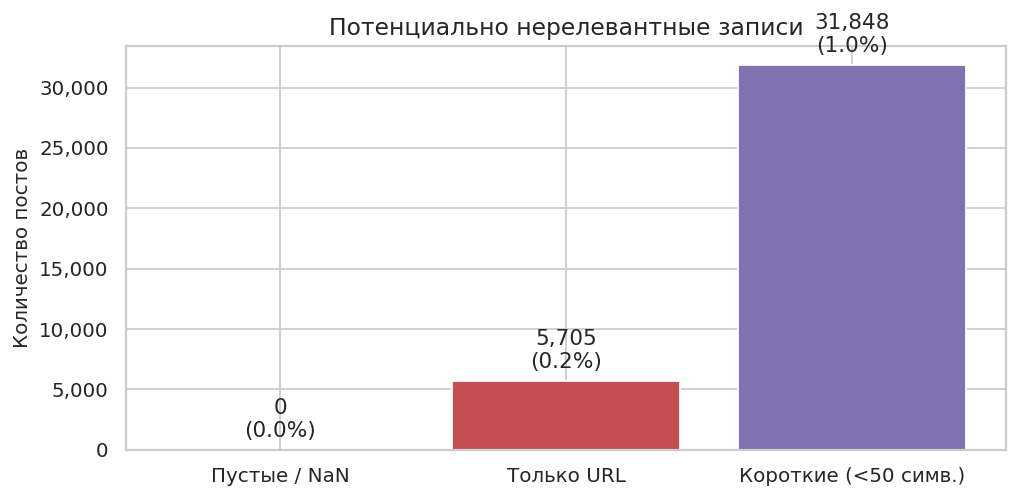

Итого записей под фильтрацию: ~31,848 (1.0%)
(короткие посты включают пустые и URL-only)


In [29]:
empty_mask   = raw_df["text"].isna() | (raw_df["text"].str.strip() == "")
url_only_mask = raw_df["text"].fillna("").str.match(r"^https?://\S+\s*$")
very_short_mask = raw_df["text_len"] < min_text_len

n_empty    = empty_mask.sum()
n_url      = url_only_mask.sum()
n_short    = very_short_mask.sum()
n_total    = len(raw_df)

categories = ["Пустые / NaN", "Только URL", f"Короткие (<{min_text_len} симв.)"]
counts     = [n_empty, n_url, n_short]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(categories, counts, color=["#DD8452", "#C44E52", "#8172B2"])
ax.bar_label(bars, labels=[f"{c:,}\n({c/n_total*100:.1f}%)" for c in counts], padding=5)
ax.set_title("Потенциально нерелевантные записи")
ax.set_ylabel("Количество постов")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("figures/04_data_quality.png", bbox_inches="tight")
plt.show()

print(f"Итого записей под фильтрацию: ~{n_short:,} ({n_short/n_total*100:.1f}%)")
print("(короткие посты включают пустые и URL-only)")

**Наблюдения:**
- Пустых записей нет (0.0%), данные хорошего качества
- 0.2% постов состоят только из URL и не несут информативной нагрузки
- Итого под фильтрацию попадает ~1% записей (31 848)
- После фильтрации рабочий корпус составит ~3 003 217 документов

**Вывод:** Датасет пригоден для тематического моделирования, требуется минимальная фильтрация (~1% записей)

На этапе предобработки будут применены:
- удаление коротких постов (<50 симв.)
- очистка от URL, эмодзи и markdown-разметки
- лемматизация

## Итоги EDA

| Параметр | Значение |
|---|---|
| Всего записей | 3 035 065 |
| Уникальных каналов | 67 |
| Временной диапазон | 2015–2025 |
| Медианная длина поста | 358 симв. |
| Записей под фильтрацию | 31 848 (1.0%) |
| Сезонный дисбаланс | отсутствует |

**Ключевые выводы для диссертации:**
1. Датасет обладает достаточным объемом (3M документов) для обучения BERTopic
2. Равномерное сезонное покрытие обеспечивает корректность темпоральных экспериментов
3. Качество данных высокое, фильтрация необходима по-минимуму
4. Рост объема публикаций подтверждает актуальность задачи мониторинга новостного потока

Дальнейший шаг описан в `02_preprocessing.ipynb` - очистка и подготовка двух версий текста
(raw для эмбеддингов, лемматизированный для c-TF-IDF)